#ML FINAL EXAM

### Email: pretabinda@gmail.com

Task: Copy this notebook on your drive and answer in that copy

Choose a dataset of your choice from kaggle or UCI

Some suggestions:https://www.kaggle.com/datasets/ahmettezcantekin/beginner-datasets

You may choose a dataset of your choice too

In this exam:
1. Provide code and explaination(in text cell) whenever needed and you must show the outputs
2. Before submitting run all cells and make sure the outputs are visible


In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Wine dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "tawfikelmetwally/wine-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.sample(7)

/tmp/ipykernel_1741/275589451.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 11.2k/11.2k [00:00<00:00, 14.8MB/s]


,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
52,1,13.82,1.75,2.42,14.0,111,3.88,3.74,0.32,1.87,7.05,1.01,3.26,1190
92,2,12.69,1.53,2.26,20.7,80,1.38,1.46,0.58,1.62,3.05,0.96,2.06,495
53,1,13.77,1.90,2.68,17.1,115,3.00,2.79,0.39,1.68,6.30,1.13,2.93,1375
42,1,13.88,1.89,2.59,15.0,101,3.25,3.56,0.17,1.70,5.43,0.88,3.56,1095
127,2,11.79,2.13,2.78,28.5,92,2.13,2.24,0.58,1.76,3.00,0.97,2.44,466
119,2,12.00,3.43,2.00,19.0,87,2.00,1.64,0.37,1.87,1.28,0.93,3.05,564
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, r2_score, mean_squared_error

## 0. Dataset overview

Why you choose this dataset and what did you observe from the dataset description



  

## Answer:


I choose this dataset because from the others questions i have noticed that I have to use same dataset for supervised and unsupervised models. So, I needed a dataset which has average num of features and most of them are numeric (as they are easy to train). That's why I choosed this dataset.

<br>
From the dataset description from kaggle, I have ovserved that, the output of the dataset represents in three classes (3 types of wines). So, this dataset is most likely have to solve with classification. And there are 13 features.


# 1. Dataset description (15 marks)


### Dataset Description
1. How many features?
2. Classification or regression problem? Why do you think so?
3. How many data points?
4. Is there any null values?
5. What kind of features are in your dataset? (Quantitative / Categorical)
6. Do you need to encode the categorical variables, why or why not?
7. Correlation of all the features, What do you understand after the correlation test?
8. Perform exploratory data analysis to extract some important relationships from your data.


Provide necessary codes and explanation

In [ ]:
print("1. Number of features: ", len(df.columns))
print("2. This is an classification Problem, as it represents three types of wines.")
print("3. Number of Data points:", df.shape[0])


1. Number of features:  14
2. This is an classification Problem, as it represents three types of wines.
3. Number of Data points: 178


In [ ]:
df.isnull().sum()


,0
class,0
Alcohol,0
Malic acid,0
Ash,0
Alcalinity of ash,0
Magnesium,0
Total phenols,0
Flavanoids,0
Nonflavanoid phenols,0
Proanthocyanins,0


4. No Null values in here.
5. All features are Quantitative (Numerical) features.
6. No need to encode because all are Numerical features.


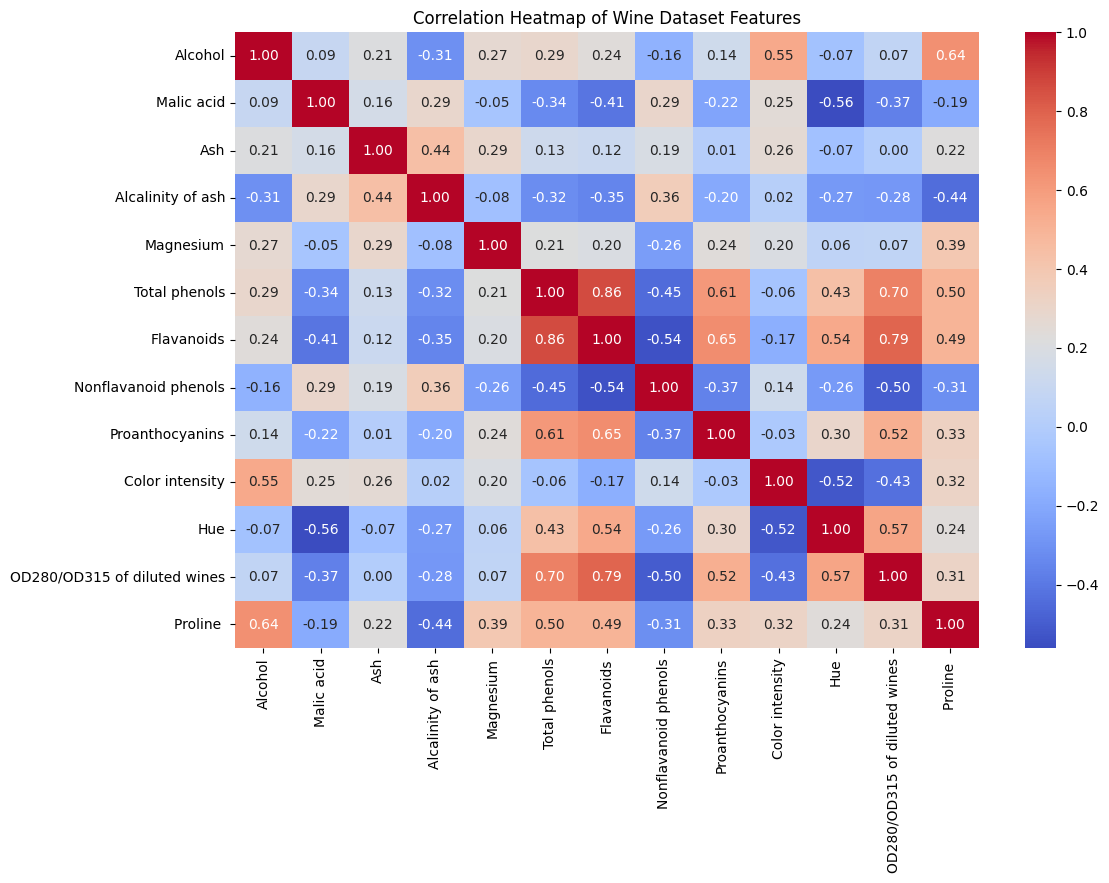

In [ ]:
features = df.drop("class", axis=1)
correlation_matrix = features.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Wine Dataset Features")
plt.show()

7. From the correlation analysis, I found that some features in the Wine dataset are strongly correlated with each other. Total Phenols and Flavanoids have a strong positive correlation (0.86), while Flavanoids and OD280/OD315 also show a strong positive correlation (0.79). Some features have moderate negative correlations, such as Malic Acid and Hue (-0.56). This indicates that there is some redundancy among the features, which suggests that dimensionality reduction techniques such as PCA can be useful.

In [ ]:
# 8. EDA

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malic acid                    178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity of ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280/OD315 of diluted wines  178 non-null    float64
 13  Proli

In [ ]:
df.describe()

,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


Maybe Proline and color intensity has outliers because their max value differs a lot from 75% value

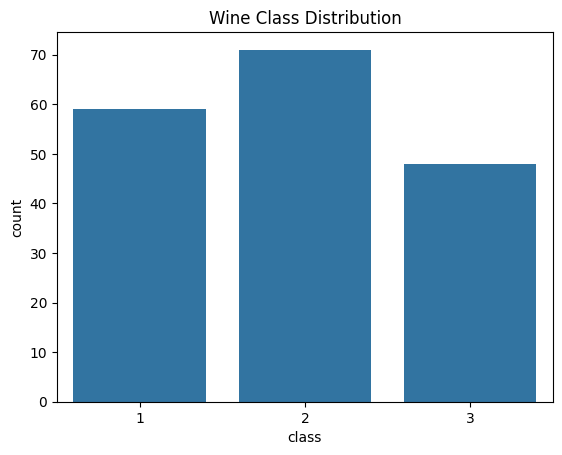

In [ ]:
sns.countplot(x='class', data=df)

plt.title("Wine Class Distribution")
plt.show()

class 2 has a dominance. so stratify is needed.

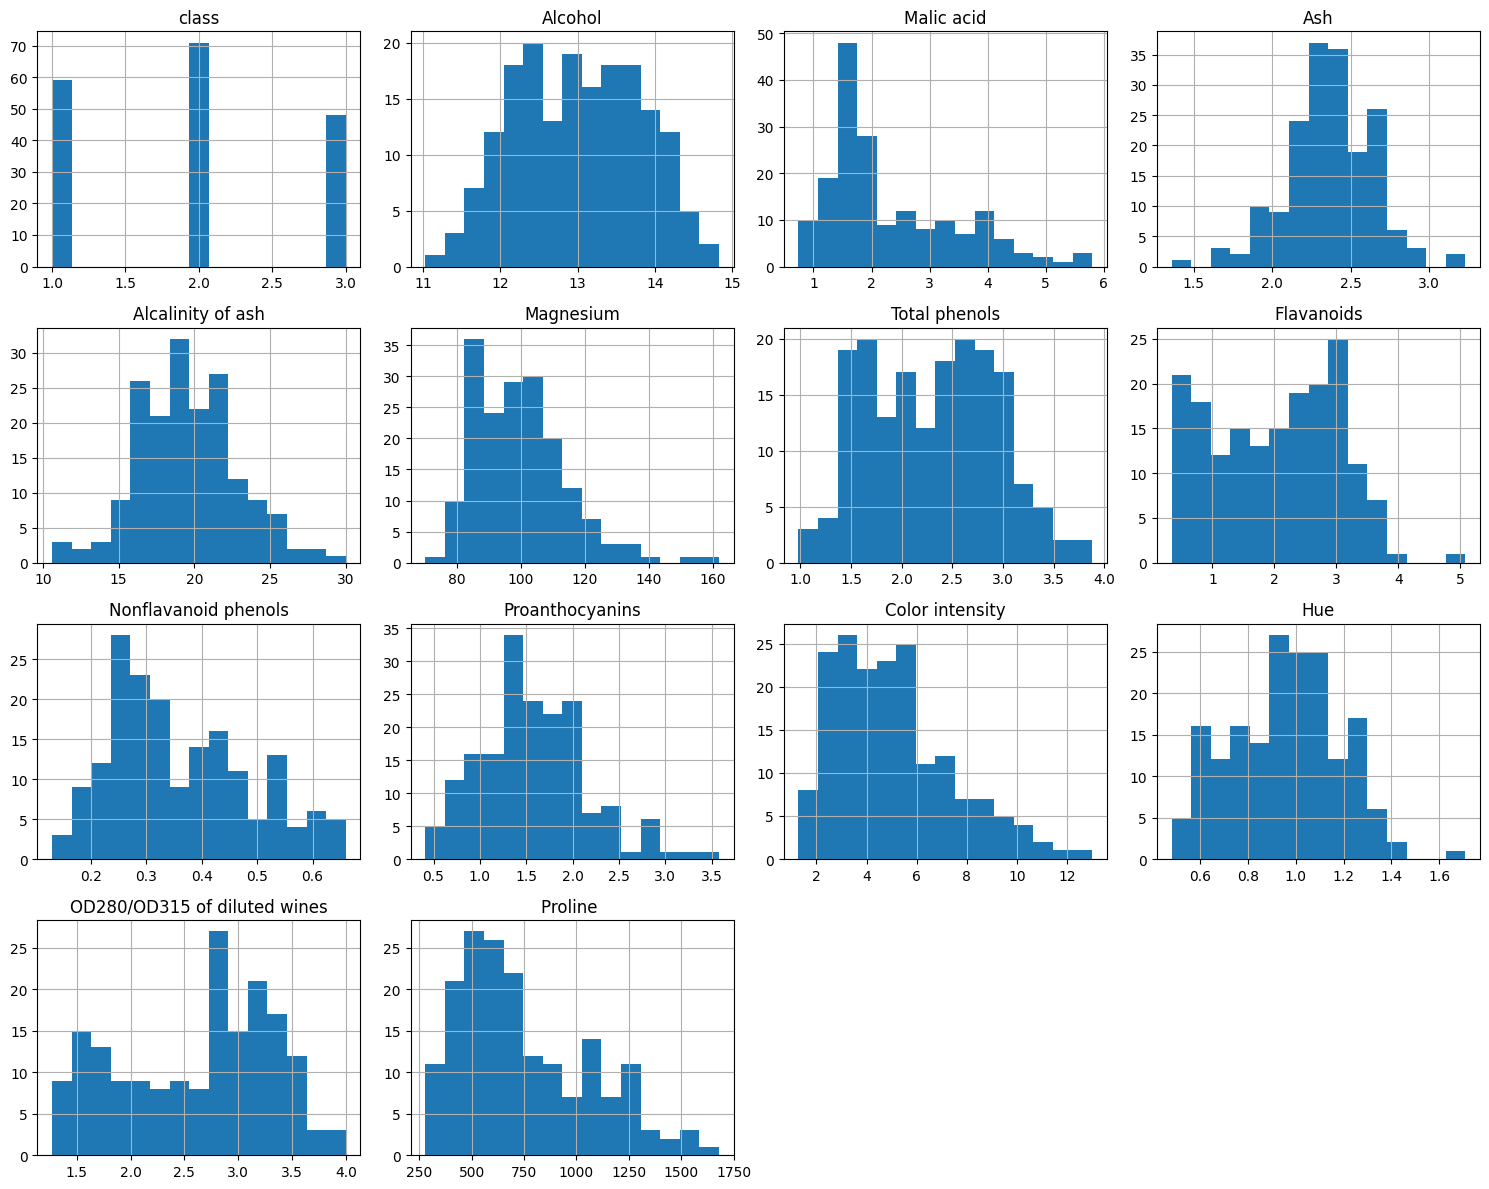

In [ ]:
df.hist(figsize=(15, 12), bins=15)

plt.tight_layout()
plt.show()

A lot of features are right skewed

8. EDA was performed using description, info, distribution, scatter plots, and correlation analysis (heatmap). The analysis revealed several important relationships. Like, Total Phenols and Flavanoids showed a strong positive correlation (0.86), while Flavanoids and OD280/OD315 also showed a strong positive correlation (0.79). Malic Acid and Hue showed a moderate negative correlation (-0.56). These relationships indicates that some features contain overlapping information, which suggests that maybe PCA can be useful.

#2. Dataset pre-processing (15 marks)

1. Provide code
2. Discuss the pre processing steps you applied and why?


## Answer:


   

In [ ]:
df.isnull().sum()

,0
class,0
Alcohol,0
Malic acid,0
Ash,0
Alcalinity of ash,0
Magnesium,0
Total phenols,0
Flavanoids,0
Nonflavanoid phenols,0
Proanthocyanins,0


In [ ]:
df.sample(10)

,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
15,1,13.63,1.81,2.70,17.2,112,2.85,2.91,0.30,1.46,7.30,1.28,2.88,1310
127,2,11.79,2.13,2.78,28.5,92,2.13,2.24,0.58,1.76,3.00,0.97,2.44,466
164,3,13.78,2.76,2.30,22.0,90,1.35,0.68,0.41,1.03,9.58,0.70,1.68,615
7,1,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295
144,3,12.25,3.88,2.20,18.5,112,1.38,0.78,0.29,1.14,8.21,0.65,2.00,855
42,1,13.88,1.89,2.59,15.0,101,3.25,3.56,0.17,1.70,5.43,0.88,3.56,1095
109,2,11.61,1.35,2.70,20.0,94,2.74,2.92,0.29,2.49,2.65,0.96,3.26,680
112,2,11.76,2.68,2.92,20.0,103,1.75,2.03,0.60,1.05,3.80,1.23,2.50,607
146,3,13.88,5.04,2.23,20.0,80,0.98,0.34,0.40,0.68,4.90,0.58,1.33,415
85,2,12.67,0.98,2.24,18.0,99,2.20,1.94,0.30,1.46,2.62,1.23,3.16,450


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malic acid                    178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity of ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280/OD315 of diluted wines  178 non-null    float64
 13  Proli

In [ ]:
df.describe()

,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


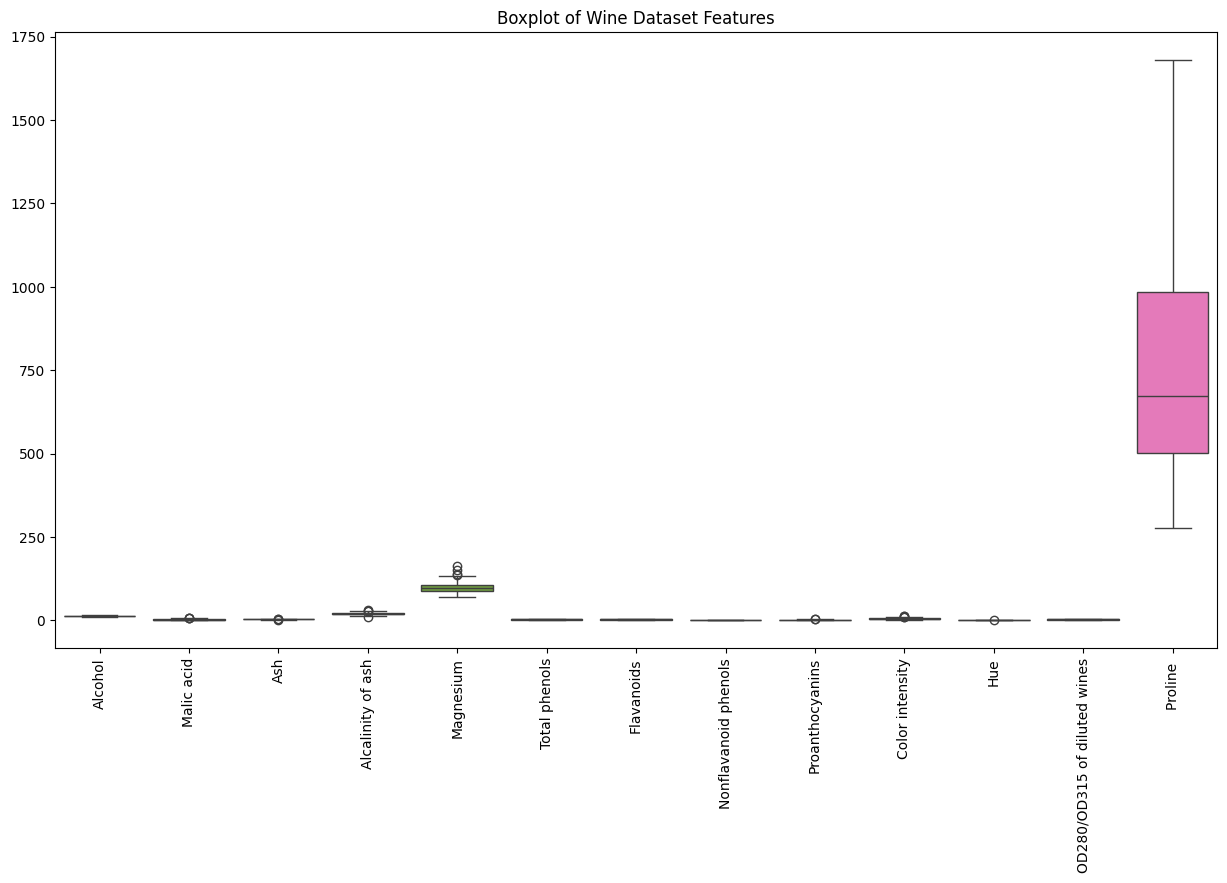

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))

sns.boxplot(data=df.drop('class', axis=1))

plt.xticks(rotation=90)
plt.title("Boxplot of Wine Dataset Features")
plt.show()

In [ ]:
# outliers using IQR

features = df.drop('class', axis=1)
outlier_counts = {}

for column in features.columns:
    Q1 = features[column].quantile(0.25)
    Q3 = features[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = features[
        (features[column] < lower_bound) |
        (features[column] > upper_bound)
    ]

    outlier_counts[column] = len(outliers)

print(outlier_counts)

{'Alcohol': 0, 'Malic acid': 3, 'Ash': 3, 'Alcalinity of ash': 4, 'Magnesium': 4, 'Total phenols': 0, 'Flavanoids': 0, 'Nonflavanoid phenols': 0, 'Proanthocyanins': 2, 'Color intensity': 4, 'Hue': 1, 'OD280/OD315 of diluted wines': 0, 'Proline ': 0}


Outliers were identified using boxplots and the IQR method. Some potential outliers were observed in features such as Malic Acid, Magnesium, Color Intensity, and Proline. However, these observations were not automatically removed because they may represent valid wine measurements rather than data-entry errors. Therefore, the identified outliers were retained for further analysis.

Preprocessing steps applied:
- searched for duplicated data using df.duplicated(): Because if there are duplicated data then model can be biased and can give wrong predictions
- searched for Null values using df.isnull(): Because model can learn pattern from incomplete or null values which will mislead
- looked for outliers using boxplot and IQR method: Because outliers can mislead the model


#3.Feature selection and Dataset splitting (10 marks)

1. Which features you wanna keep ? Justify and drop and rest or apply any other feature engineering step
2. Perform Train test split

## Answer:



In [ ]:
# Feature Selection
X = df.drop(columns=['class', 'Total phenols'])
y = df['class']

- Based on the previous correlation analysis, we have seen that total phenols and Flavanoids has a correlation of 0.86. so we can remove one of them, but it should be removed based on trial and error method by checking the accuracy of the model.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#4.  Pipeline Creation (Supervised) (10 marks)

Select 2 models of your choice and build 2 pipelines for them

## Answer:

In [ ]:
logistic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression())
])

KNN_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier())
])

# 5. Model Training (5 marks)

Train those 2 models



## Answer:

In [ ]:
logistic_pipeline.fit(X_train, y_train)
KNN_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', KNeighborsClassifier())])

#6. Model selection/Comparison analysis (15 marks)
* Bar chart showcasing prediction accuracy of all models (for classification)
* Precision, recall comparison of each model. (for classification)
* Confusion Matrix (for classification)
* R2 score and Loss  (for regression)

Compare the results of all models based on all of the above described metrics. Why do you think this model performed better than the other one for this dataset?

# Answer:

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Predict on the test set......
y_pred_logistic = logistic_pipeline.predict(X_test)
y_pred_knn = KNN_pipeline.predict(X_test)

models = {
    "Logistic Regression": y_pred_logistic,
    "KNN": y_pred_knn
}

results = []
for model_name, y_pred in models.items():
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    results.append([model_name, accuracy, precision, recall])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall"]
)

print("Model Comparison:")
display(results_df)


Model Comparison:


,Model,Accuracy,Precision,Recall
0,Logistic Regression,1.0,1.0,1.0
1,KNN,1.0,1.0,1.0


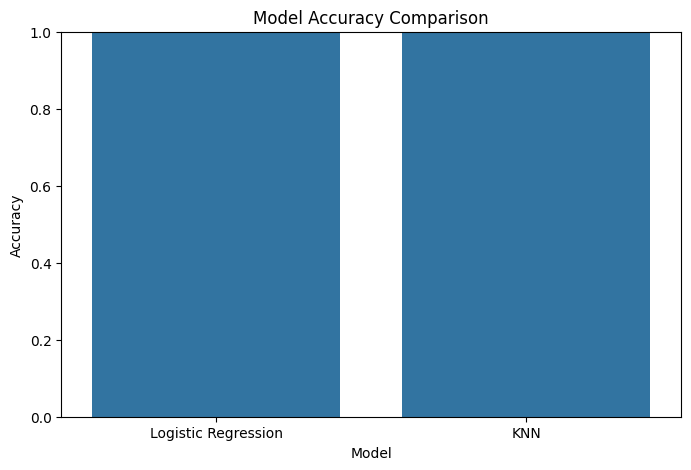

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

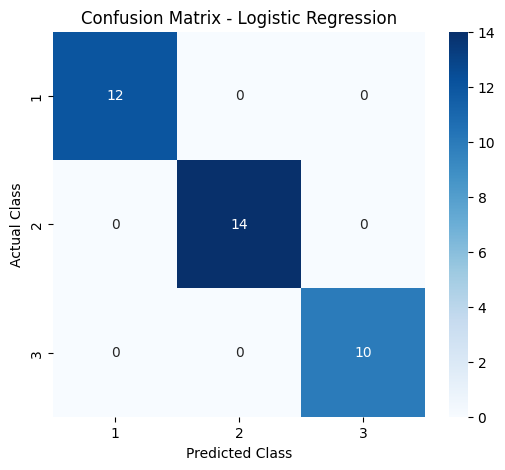

In [ ]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1, 2, 3],
    yticklabels=[1, 2, 3]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

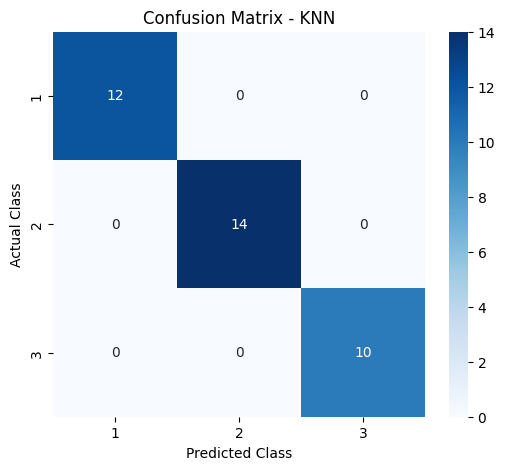

In [ ]:
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1, 2, 3],
    yticklabels=[1, 2, 3]
)

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

# 7. Treating the problem as Unsupervised (20 marks) ( Explore the topic as you wish )

1. Treat the problem as a unsupervised problem and perform any unsupervised model and evalute the result
2. Which method worked better? supervised or unsupervised approach and why?

# Answer:

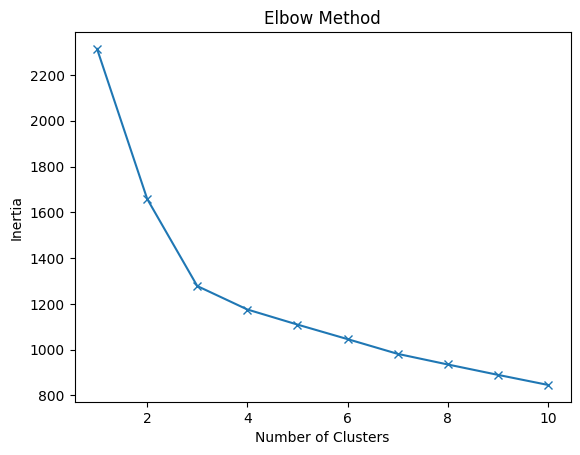

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

X_unsupervised = df.drop(columns=['class'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsupervised)

# finding K=? using Elbow Method
inertias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='x')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


In [ ]:
kmeans = KMeans(
    n_clusters=3, # taking k = 3
    random_state=42,
    n_init=10
)
clusters = kmeans.fit_predict(X_scaled)

In [ ]:
# for analysis, adding cluser labels:
df_unsupervised = X_unsupervised.copy()
df_unsupervised['cluster'] = clusters

silhouette = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.2848589191898987


In [ ]:
from sklearn.metrics import adjusted_rand_score
adjusted_rand_score(df['class'], clusters)

0.8974949815093207

The supervised approach worked better because the model was trainned using known labels and some features were very spread, so that may effect the unsupervised learning.

#8. Self Reflection on this machine learning course (10 marks)

Explain the hardest and the easiest topic of this course according to you in a intuitive way (you may also provide real world implementation , necessity etc along with the explaination)

##Answer:

The hardest part of this course was to understood the data, which feature you should keep, which should be removed. Or how to fill null values, how to make new features, which scaling have to use etc. So, I think EDA is one of the important and hardest part of this course. And model trainings are the easiest, because if i don't know anything, AI can help me in this part. But if I have to do a proper EDA, then I have to understand the data in the eyes of business.